# Ex No 5 - Develop a python program for Skin color Detection 


Number of Face Images Loaded: 32
Image: 0520962400.jpg
Skin Pixels: 13636
Skin Percentage: 16.52%
--------------------------------


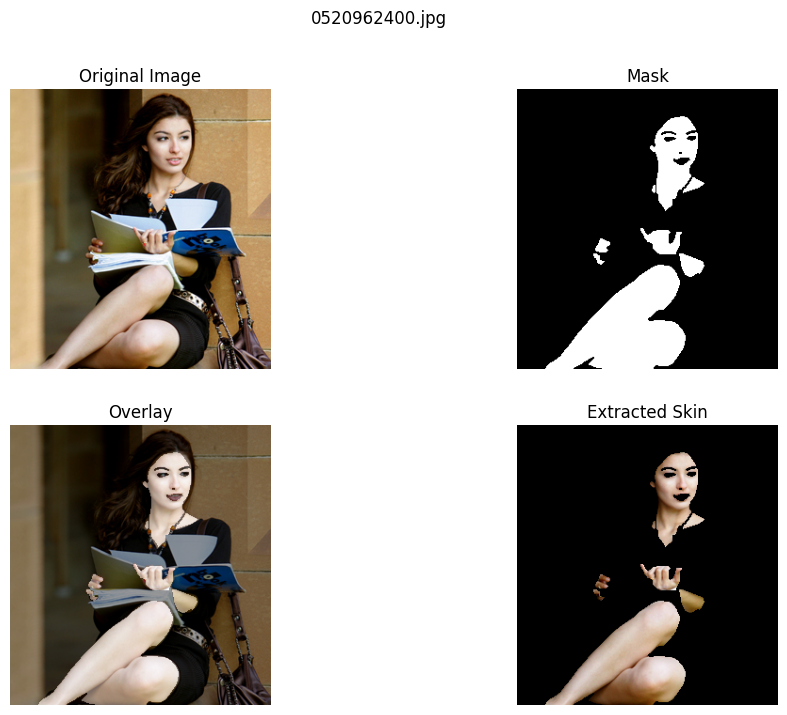

Image: 06Apr03Face.jpg
Skin Pixels: 82792
Skin Percentage: 44.57%
--------------------------------


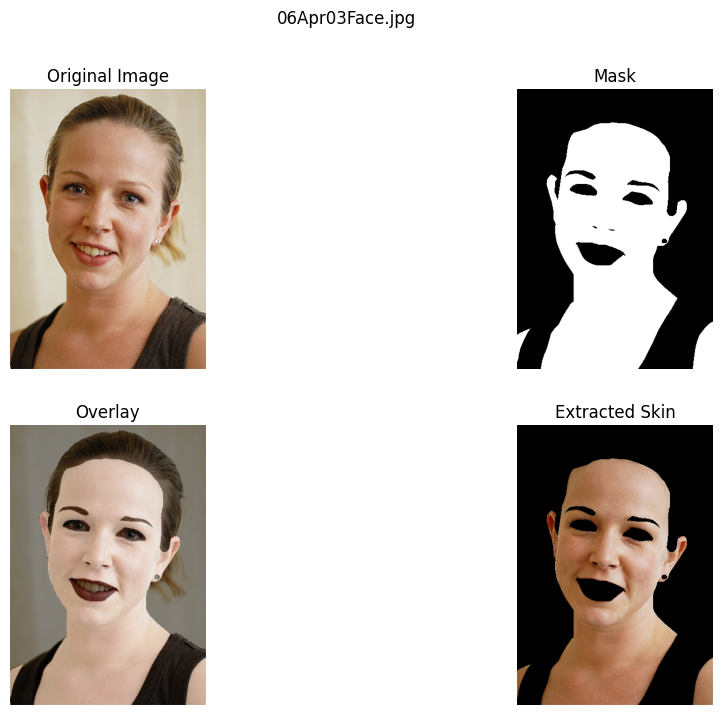

Image: 124511719065943_2.jpg
Skin Pixels: 22176
Skin Percentage: 17.03%
--------------------------------


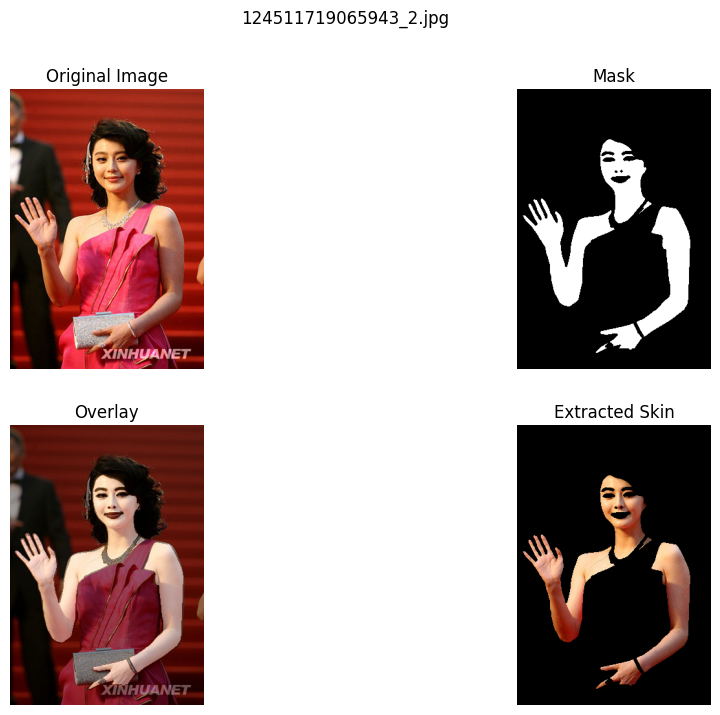

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

%matplotlib inline

# -------------------------------
# Dataset paths
# -------------------------------
face_dir = r"D:\SEM 6\IPCV\FacePhoto"
mask_dir = r"D:\SEM 6\IPCV\GroundT_FacePhoto"


# -------------------------------
# Load Images
# -------------------------------
def load_images(image_folder, mask_folder):

    images = []
    masks = []
    names = []

    image_files = os.listdir(image_folder)
    mask_files = os.listdir(mask_folder)

    for img_file in image_files:

        name = os.path.splitext(img_file)[0]   # filename without extension

        # Find corresponding mask
        for mask_file in mask_files:

            mask_name = os.path.splitext(mask_file)[0]

            if name == mask_name:

                img_path = os.path.join(image_folder, img_file)
                mask_path = os.path.join(mask_folder, mask_file)

                image = imageio.imread(img_path)
                mask = imageio.imread(mask_path)

                images.append(image)
                masks.append(mask)
                names.append(img_file)

                break

    return images, masks, names


# -------------------------------
# Skin Extraction
# -------------------------------
def extract_skin(image, mask):

    mask_rgb = mask[:, :, :3]

    skin_pixels = np.all(mask_rgb == [255, 255, 255], axis=-1)

    skin_image = np.zeros_like(image)

    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels


# -------------------------------
# Display Results
# -------------------------------
def display_results(image, mask, skin_image, name):

    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.suptitle(name)
    plt.show()


# -------------------------------
# Load Dataset
# -------------------------------
images, masks, names = load_images(face_dir, mask_dir)

print("Number of Face Images Loaded:", len(images))


# -------------------------------
# Process Images
# -------------------------------
for i in range(len(images)):

    image = images[i]
    mask = masks[i]
    name = names[i]

    skin_image, skin_pixels = extract_skin(image, mask)

    total_pixels = skin_pixels.size
    skin_count = np.sum(skin_pixels)

    skin_percentage = (skin_count / total_pixels) * 100

    print("Image:", name)
    print("Skin Pixels:", skin_count)
    print("Skin Percentage: %.2f%%" % skin_percentage)
    print("--------------------------------")

    display_results(image, mask, skin_image, name)

    # Show only first 3 images
    if i == 2:
        break